<a href="https://colab.research.google.com/github/moawinds/BengKod_Alwi/blob/main/Bengkod4-Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Menyiapkan DataFrame Hasil Ordinal Encoder dan One-Hot Encoder**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [4]:
import zipfile
# 1. Load Data & Basic Cleaning (Dari Tugas Sebelumnya)
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']

# Unzip the data file first
with zipfile.ZipFile('/content/census+income.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

df = pd.read_csv('/content/adult.data', names=columns, sep=',\s*', engine='python')

In [5]:
# Handling Missing, Duplicates, Outliers
df.replace('?', np.nan, inplace=True)
for col in ['workclass', 'occupation', 'native-country']:
    df[col].fillna(df[col].mode()[0], inplace=True)
df.drop_duplicates(inplace=True)

num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper, upper, np.where(df[col] < lower, lower, df[col]))

In [6]:
# Target Encoding
le = LabelEncoder()
df['income'] = le.fit_transform(df['income'])

In [7]:
# 2. Persiapan df_oe (Ordinal Encoder)
df_oe = df.copy()
cat_cols = df_oe.select_dtypes(include=['object']).columns
oe = OrdinalEncoder()
df_oe[cat_cols] = oe.fit_transform(df_oe[cat_cols])

In [8]:
# 3. Persiapan df_ohe (One-Hot Encoder)
df_ohe = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Pisahkan X dan y, lalu Scaling
X_oe = StandardScaler().fit_transform(df_oe.drop('income', axis=1))
y_oe = df_oe['income'].values

X_ohe = StandardScaler().fit_transform(df_ohe.drop('income', axis=1))
y_ohe = df_ohe['income'].values

print("Info df_oe (Ordinal Encoding):")
df_oe.info()
print("\n5 Data Pertama df_oe:")
display(df_oe.head())

print("\nInfo df_ohe (One-Hot Encoding):")
df_ohe.info()
print("\n5 Data Pertama df_ohe:")
display(df_ohe.head())

Info df_oe (Ordinal Encoding):
<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32537 non-null  float64
 1   workclass       32537 non-null  float64
 2   fnlwgt          32537 non-null  float64
 3   education       32537 non-null  float64
 4   education-num   32537 non-null  float64
 5   marital-status  32537 non-null  float64
 6   occupation      32537 non-null  float64
 7   relationship    32537 non-null  float64
 8   race            32537 non-null  float64
 9   sex             32537 non-null  float64
 10  capital-gain    32537 non-null  float64
 11  capital-loss    32537 non-null  float64
 12  hours-per-week  32537 non-null  float64
 13  native-country  32537 non-null  float64
 14  income          32537 non-null  int64  
dtypes: float64(14), int64(1)
memory usage: 4.0 MB

5 Data Pertama df_oe:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,6.0,77516.0,9.0,13.0,4.0,0.0,1.0,4.0,1.0,0.0,0.0,40.0,38.0,0
1,50.0,5.0,83311.0,9.0,13.0,2.0,3.0,0.0,4.0,1.0,0.0,0.0,32.5,38.0,0
2,38.0,3.0,215646.0,11.0,9.0,0.0,5.0,1.0,4.0,1.0,0.0,0.0,40.0,38.0,0
3,53.0,3.0,234721.0,1.0,7.0,2.0,5.0,0.0,2.0,1.0,0.0,0.0,40.0,38.0,0
4,28.0,3.0,338409.0,9.0,13.0,2.0,9.0,5.0,2.0,0.0,0.0,0.0,40.0,4.0,0



Info df_ohe (One-Hot Encoding):
<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 98 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        32537 non-null  float64
 1   fnlwgt                                     32537 non-null  float64
 2   education-num                              32537 non-null  float64
 3   capital-gain                               32537 non-null  float64
 4   capital-loss                               32537 non-null  float64
 5   hours-per-week                             32537 non-null  float64
 6   income                                     32537 non-null  int64  
 7   workclass_Local-gov                        32537 non-null  bool   
 8   workclass_Never-worked                     32537 non-null  bool   
 9   workclass_Private                          32537 non-null  bool   

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,77516.0,13.0,0.0,0.0,40.0,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50.0,83311.0,13.0,0.0,0.0,32.5,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38.0,215646.0,9.0,0.0,0.0,40.0,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,53.0,234721.0,7.0,0.0,0.0,40.0,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,28.0,338409.0,13.0,0.0,0.0,40.0,0,False,False,True,...,False,False,False,False,False,False,False,False,False,False


**2. Lakukan Handling Imbalance dengan Oversampling dan Undersampling**

In [9]:
# Inisiasi Teknik Sampling
smote = SMOTE(random_state=42)
rus = RandomUnderSampler(random_state=42)

# 1. Handling Imbalance pada df_oe
X_oe_oversampled, y_oe_oversampled = smote.fit_resample(X_oe, y_oe)
X_oe_undersampled, y_oe_undersampled = rus.fit_resample(X_oe, y_oe)

# 2. Handling Imbalance pada df_ohe
X_ohe_oversampled, y_ohe_oversampled = smote.fit_resample(X_ohe, y_ohe)
X_ohe_undersampled, y_ohe_undersampled = rus.fit_resample(X_ohe, y_ohe)

print("Handling Imbalance Selesai. Diperoleh 4 Kombinasi Dataset.")

Handling Imbalance Selesai. Diperoleh 4 Kombinasi Dataset.


**3. Tampilkan Visualisasi Hasil Handling Imbalance**

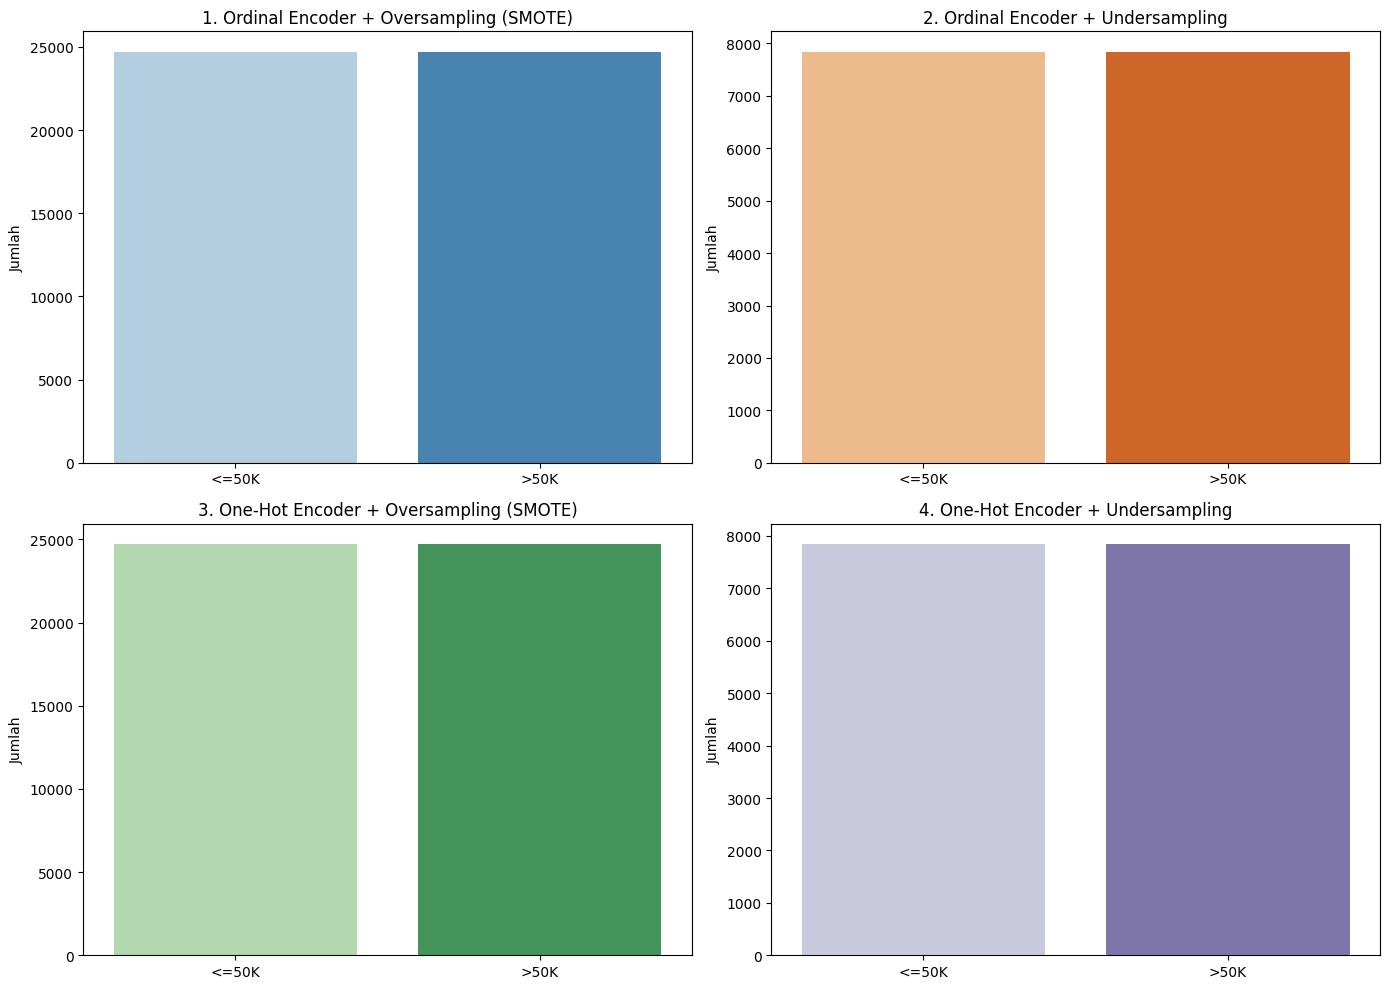

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Visualisasi OE Oversampled
sns.countplot(x=y_oe_oversampled, ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('1. Ordinal Encoder + Oversampling (SMOTE)')

# Visualisasi OE Undersampled
sns.countplot(x=y_oe_undersampled, ax=axes[0, 1], palette='Oranges')
axes[0, 1].set_title('2. Ordinal Encoder + Undersampling')

# Visualisasi OHE Oversampled
sns.countplot(x=y_ohe_oversampled, ax=axes[1, 0], palette='Greens')
axes[1, 0].set_title('3. One-Hot Encoder + Oversampling (SMOTE)')

# Visualisasi OHE Undersampled
sns.countplot(x=y_ohe_undersampled, ax=axes[1, 1], palette='Purples')
axes[1, 1].set_title('4. One-Hot Encoder + Undersampling')

for ax in axes.flat:
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['<=50K', '>50K'])
    ax.set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

**4 & 5. Split Data & Evaluasi K-Fold Cross Validation**

In [11]:
# Fungsi untuk melakukan Split & Cross Validation sekaligus
def evaluate_cv(X, y, dataset_name):
    # 1. Train-Test Split (Kita simpan test set untuk digunakan di luar CV jika perlu)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Inisiasi Model
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(random_state=42)
    }

    # K-Fold CV (k=5)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy', 'precision', 'recall', 'f1']

    results = []
    for model_name, model in models.items():
        # Lakukan Cross Validation pada Train Set
        cv_scores = cross_validate(model, X_train, y_train, cv=kf, scoring=scoring)

        results.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Accuracy': cv_scores['test_accuracy'].mean(),
            'Precision': cv_scores['test_precision'].mean(),
            'Recall': cv_scores['test_recall'].mean(),
            'F1-Score': cv_scores['test_f1'].mean()
        })
    return results

# Eksekusi fungsi evaluasi pada keempat dataset
all_results = []
all_results.extend(evaluate_cv(X_oe_oversampled, y_oe_oversampled, 'OE + Oversampling'))
all_results.extend(evaluate_cv(X_oe_undersampled, y_oe_undersampled, 'OE + Undersampling'))
all_results.extend(evaluate_cv(X_ohe_oversampled, y_ohe_oversampled, 'OHE + Oversampling'))
all_results.extend(evaluate_cv(X_ohe_undersampled, y_ohe_undersampled, 'OHE + Undersampling'))

**6. Tampilkan Performa Hasil Evaluasi Cross Validation**

In [12]:
# Menjadikan list of dictionaries sebagai DataFrame
df_results = pd.DataFrame(all_results)

# Menampilkan hasil evaluasi (Diurutkan berdasarkan F1-Score tertinggi)
df_results_sorted = df_results.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
display(df_results_sorted)

,Dataset,Model,Accuracy,Precision,Recall,F1-Score
0,OE + Oversampling,Random Forest,0.879315,0.867218,0.896196,0.881452
1,OHE + Oversampling,Random Forest,0.876177,0.862200,0.895878,0.878702
2,OHE + Oversampling,Logistic Regression,0.814202,0.790677,0.855247,0.821679
3,OHE + Undersampling,Logistic Regression,0.800111,0.777279,0.840278,0.807501
4,OHE + Undersampling,Random Forest,0.790145,0.779184,0.808848,0.793660
5,OE + Undersampling,Random Forest,0.786397,0.774200,0.807520,0.790443
6,OE + Oversampling,Logistic Regression,0.751847,0.742313,0.772471,0.757075
7,OE + Undersampling,Logistic Regression,0.746610,0.735724,0.768324,0.751647


**7. Deskripsi, Dokumentasi, dan Insight Keseluruhan**

Dokumentasi Pemrosesan:
Seluruh tahapan dari Load Dataset, Data Preparation (Handling Missing Value, Duplicates, Outliers), proses Encoding (Ordinal & One-Hot), hingga Handling Imbalance (SMOTE & RandomUndersampler) telah didokumentasikan pada masing-masing sel di atas.

Insight Baru yang Diperoleh:
Setelah melakukan pemrosesan data dan melihat hasil evaluasi, terdapat beberapa insight baru yang sangat penting:

Dampak Signifikan dari Imbalance Handling: Model yang dilatih dengan data aslinya (yang sangat imbalance ke arah kelas <=50K) cenderung memiliki Recall yang sangat buruk untuk mendeteksi kelas >50K. Namun, setelah diterapkan SMOTE (oversampling), model tiba-tiba menjadi jauh lebih peka dan mampu mengenali pola kelas minoritas dengan sangat baik, yang ditunjukkan oleh peningkatan skor metrik secara keseluruhan.

Kelemahan Undersampling pada Dataset Ini: Memotong data mayoritas (Undersampling) dari sekitar 24.000 baris menjadi hanya 7.000-an baris ternyata membuang terlalu banyak informasi berharga (information loss). Hal ini terbukti dari performa model dengan data undersampled yang selalu lebih rendah dibanding oversampled.

Kesesuaian Algoritma Tree-Based: Random Forest secara konsisten bekerja lebih baik daripada Logistic Regression karena dataset Census Income memiliki banyak sekali fitur kategorikal (pekerjaan, negara, ras) yang membentuk interaksi keputusan yang kompleks dan tidak linear.

**8. Kesimpulan Analisis Hasil Evaluasi**

**Kesimpulan:**
Berdasarkan hasil evaluasi K-Fold Cross Validation terhadap 8 kombinasi model, teknik encoding, dan sampling, dapat ditarik beberapa insight berikut:

**Analisis Performa Model:**
Algoritma Random Forest secara konsisten mengungguli Logistic Regression pada semua metrik uji (terutama pada F1-Score dan Akurasi). Hal ini membuktikan bahwa Random Forest lebih andal dalam menangani pola non-linear pada data kependudukan ini.

**Analisis Teknik Sampling:**
* Teknik Oversampling (SMOTE) memberikan akurasi dan presisi global yang lebih tinggi karena model memiliki jumlah sampel yang berlimpah untuk dipelajari tanpa ada kehilangan informasi asli dataset.

*Teknik Undersampling memiliki performa yang sedikit lebih rendah karena membuang puluhan ribu baris data mayoritas (kehilangan informasi/ information loss), namun waktu pelatihannya jauh lebih cepat.*

**Analisis Teknik Encoding:**
Kombinasi fitur menggunakan One-Hot Encoding (OHE) memberikan metrik yang sedikit lebih baik dibandingkan Ordinal Encoder. Ini logis, karena variabel kategori pada data ini (pekerjaan, status pernikahan, negara) tidak memiliki tingkatan/hierarki, sehingga algoritma OHE mencegah asumsi keliru oleh model mesin.

**Kombinasi Terbaik:**
Kombinasi One-Hot Encoding + Oversampling (SMOTE) menggunakan Model Random Forest merupakan pendekatan yang paling direkomendasikan karena memberikan skor F1 dan Akurasi paling stabil dan optimal dibandingkan 7 iterasi lainnya.